In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Datasprint_Ultimate"
import os
os.makedirs(base_path, exist_ok=True)

print("✅ Drive Ready")

Mounted at /content/drive
✅ Drive Ready


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import os

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Device:", device)

🚀 Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.ToTensor()
])

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

        self.id_map = {}
        for path in image_paths:
            vid = path.split('/')[-1].split('_')[0]
            self.id_map.setdefault(vid, []).append(path)

        self.ids = list(self.id_map.keys())

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        while True:
            anchor_path = self.image_paths[idx]
            vid = anchor_path.split('/')[-1].split('_')[0]

            pos_path = np.random.choice(self.id_map[vid])

            neg_id = np.random.choice(self.ids)
            while neg_id == vid:
                neg_id = np.random.choice(self.ids)
            neg_path = np.random.choice(self.id_map[neg_id])

            def load(path):
                img = cv2.imread(path)
                if img is None:
                    return None
                img = cv2.resize(img, (128,128))
                return self.transform(img)

            a = load(anchor_path)
            p = load(pos_path)
            n = load(neg_path)

            if a is not None and p is not None and n is not None:
                return a, p, n

            idx = (idx + 1) % len(self.image_paths)

In [ ]:
!pip install kaggle

from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rakshanamaids","key":"48cb50ca6a6564517a6598cc535e819b"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c data-sprint-veri
!unzip data-sprint-veri.zip

Streaming output truncated to the last 5000 lines.
  inflating: VeRi/image_train/0665_c012_00062300_0.jpg  
  inflating: VeRi/image_train/0665_c012_00062310_0.jpg  
  inflating: VeRi/image_train/0665_c012_00062320_0.jpg  
  inflating: VeRi/image_train/0665_c012_00062325_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062110_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062115_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062120_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062125_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062130_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062135_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063935_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063940_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063945_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063950_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063955_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063960_0.jpg  
  inflating: VeRi/image_train/0665_c0

In [ ]:
image_folder = "/content/VeRi/image_train"

image_paths = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.endswith(".jpg")
]

dataset = TripletDataset(image_paths, transform)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

print("✅ Dataset:", len(dataset))

✅ Dataset: 37778


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride),
                nn.BatchNorm2d(out_c)
            )

        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

In [ ]:
class UltimateReID(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.layer1 = self._make_layer(32, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2)
        self.layer3 = self._make_layer(128, 256, 2)

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128)
        )

    def _make_layer(self, in_c, out_c, blocks):
        layers = [ResidualBlock(in_c, out_c, stride=2)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = self.fc(x)
        return x / x.norm(p=2, dim=1, keepdim=True)

In [ ]:
def batch_hard_triplet_loss(embeddings, margin=1.0):
    dist = torch.cdist(embeddings, embeddings)

    labels = torch.arange(embeddings.size(0)).to(device)

    loss = 0

    for i in range(len(labels)):
        pos = dist[i][i]  # same
        neg = torch.min(dist[i][dist[i] > 0])  # hardest negative

        loss += torch.clamp(pos - neg + margin, min=0)

    return loss / len(labels)

In [ ]:
# =========================
# 🔥 CHECKPOINT SETUP CELL
# =========================

import os
import torch
import torch.optim as optim

checkpoint_path = base_path + "/ultimate_checkpoint.pth"

start_epoch = 0

# 🔥 Initialize model
model = UltimateReID().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0003)

# 🔁 Load checkpoint if exists
if os.path.exists(checkpoint_path):
    print("🔁 Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])

    start_epoch = checkpoint['epoch']

    print(f"✅ Resumed from epoch {start_epoch}")

else:
    print("🚀 Starting fresh training")

🚀 Starting fresh training


In [ ]:
!rm "/content/drive/MyDrive/Datasprint_Ultimate/ultimate_checkpoint.pth"

rm: cannot remove '/content/drive/MyDrive/Datasprint_Ultimate/ultimate_checkpoint.pth': No such file or directory


In [ ]:
# =========================
# 🔥 CORRECT TRIPLET LOSS
# =========================
def triplet_loss(a, p, n, margin=1.0):
    dist_ap = torch.norm(a - p, dim=1)
    dist_an = torch.norm(a - n, dim=1)

    loss = torch.clamp(dist_ap - dist_an + margin, min=0)

    return loss.mean()


# =========================
# 🔥 TRAINING CELL (FIXED)
# =========================

EPOCHS = 25

# 🔥 Optional: LR Scheduler (improves training)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss = 0

    for a, p, n in dataloader:
        a, p, n = a.to(device), p.to(device), n.to(device)

        # 🔥 CORRECT FORWARD
        f_a = model(a)
        f_p = model(p)
        f_n = model(n)

        # 🔥 CORRECT LOSS
        loss = triplet_loss(f_a, f_p, f_n)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    print(f"🔥 Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}, LR: {optimizer.param_groups[0]['lr']}")

    # =========================
    # 💾 SAVE CHECKPOINT
    # =========================
    torch.save({
        'epoch': epoch + 1,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }, checkpoint_path)

    print("💾 Checkpoint saved")


# =========================
# 💾 SAVE FINAL MODEL
# =========================

torch.save(model.state_dict(), base_path + "/ultimate_model.pkl")

print("✅ Training Complete")

🔥 Epoch 1/25, Loss: 266.4535, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 2/25, Loss: 198.1700, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 3/25, Loss: 171.9683, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 4/25, Loss: 155.7174, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 5/25, Loss: 140.8845, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 6/25, Loss: 132.2665, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 7/25, Loss: 126.8478, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 8/25, Loss: 117.4552, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 9/25, Loss: 108.1494, LR: 0.0003
💾 Checkpoint saved
🔥 Epoch 10/25, Loss: 101.6153, LR: 0.00015
💾 Checkpoint saved
🔥 Epoch 11/25, Loss: 88.8142, LR: 0.00015
💾 Checkpoint saved
🔥 Epoch 12/25, Loss: 85.6892, LR: 0.00015
💾 Checkpoint saved
🔥 Epoch 13/25, Loss: 83.0933, LR: 0.00015
💾 Checkpoint saved
🔥 Epoch 14/25, Loss: 80.1870, LR: 0.00015
💾 Checkpoint saved
🔥 Epoch 15/25, Loss: 75.7373, LR: 0.00015
💾 Checkpoint saved
🔥 Epoch 16/25, Loss: 76.4195, LR: 0.00015
💾 Checkpoint saved
🔥 Epoch 17/25, Loss: 70.8512, LR

In [ ]:
model = UltimateReID().to(device)
model.load_state_dict(torch.load(base_path + "/ultimate_model.pkl", map_location=device))
model.eval()

print("✅ Model Ready")

✅ Model Ready


In [ ]:
transform_eval = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

def extract_features(model, folder):
    features = []
    names = []

    for fname in os.listdir(folder):
        if not fname.endswith(".jpg"):
            continue

        path = os.path.join(folder, fname)
        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, (128,128))
        img = transform_eval(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = model(img)

        features.append(feat.cpu().numpy())
        names.append(fname)

    return np.vstack(features), names

In [ ]:
query_features, query_names = extract_features(model, "/content/VeRi/image_query")
gallery_features, gallery_names = extract_features(model, "/content/VeRi/image_test")

print(query_features.shape, gallery_features.shape)

(1678, 128) (11579, 128)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(query_features, gallery_features)

print("✅ Similarity Ready")

✅ Similarity Ready


In [ ]:
predictions = []

for i, qname in enumerate(query_names):
    sims = similarity[i]
    idx = np.argsort(-sims)

    top10 = [gallery_names[j] for j in idx[:10]]
    predictions.append([qname] + top10)

import pandas as pd

columns = ["query"] + [f"match_{i}" for i in range(1,11)]
df = pd.DataFrame(predictions, columns=columns)

df.to_csv(base_path + "/ultimate_predictions.csv", index=False)

print("✅ predictions.csv saved")

✅ predictions.csv saved


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score

def get_id(name):
    return name.split('_')[0]

y_true = []
y_pred = []

for i, q in enumerate(query_names):
    qid = get_id(q)

    sims = similarity[i]
    idx = np.argsort(-sims)

    top1 = gallery_names[idx[0]]

    y_true.append(1)
    y_pred.append(1 if get_id(top1) == qid else 0)

cm = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("🔥 Confusion Matrix:\n", cm)
print("🔥 Accuracy:", accuracy)
print("🔥 Precision:", precision)
print("🔥 F1 Score:", f1)

🔥 Confusion Matrix:
 [[   0    0]
 [ 381 1297]]
🔥 Accuracy: 0.7729439809296782
🔥 Precision: 1.0
🔥 F1 Score: 0.8719327731092437


In [ ]:
# Rank-1
correct = 0

for i, q in enumerate(query_names):
    if get_id(q) == get_id(gallery_names[np.argmax(similarity[i])]):
        correct += 1

rank1 = correct / len(query_names)

print("🔥 Rank-1:", rank1)

🔥 Rank-1: 0.7723480333730631


In [ ]:
import numpy as np

def get_id(name):
    return name.split('_')[0]

def average_precision(qid, sorted_gallery):
    correct = 0
    total = 0
    score = 0

    for g in sorted_gallery:
        total += 1
        if get_id(g) == qid:
            correct += 1
            score += correct / total

    if correct == 0:
        return 0

    return score / correct


aps = []

for i, qname in enumerate(query_names):
    qid = get_id(qname)

    sims = similarity[i]
    sorted_idx = np.argsort(-sims)

    sorted_gallery = [gallery_names[j] for j in sorted_idx]

    ap = average_precision(qid, sorted_gallery)
    aps.append(ap)

mAP = np.mean(aps)

print("🔥 mAP:", mAP)

🔥 mAP: 0.14418378947729868


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

def get_id(name):
    return name.split('_')[0]

def visualize_top10(query_idx):
    query_path = "/content/VeRi/image_query"
    gallery_path = "/content/VeRi/image_test"

    qname = query_names[query_idx]
    sims = similarity[query_idx]
    sorted_idx = np.argsort(-sims)

    plt.figure(figsize=(20,4))

    # Query
    q_img = cv2.imread(os.path.join(query_path, qname))
    q_img = cv2.cvtColor(q_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,11,1)
    plt.imshow(q_img)
    plt.title("Query")
    plt.axis('off')

    # Top 10 matches
    for k in range(10):
        gname = gallery_names[sorted_idx[k]]
        g_img = cv2.imread(os.path.join(gallery_path, gname))
        g_img = cv2.cvtColor(g_img, cv2.COLOR_BGR2RGB)

        correct = get_id(qname) == get_id(gname)
        color = "green" if correct else "red"

        plt.subplot(1,11,k+2)
        plt.imshow(g_img)
        plt.title(f"{k+1}", color=color)
        plt.axis('off')

    plt.show()

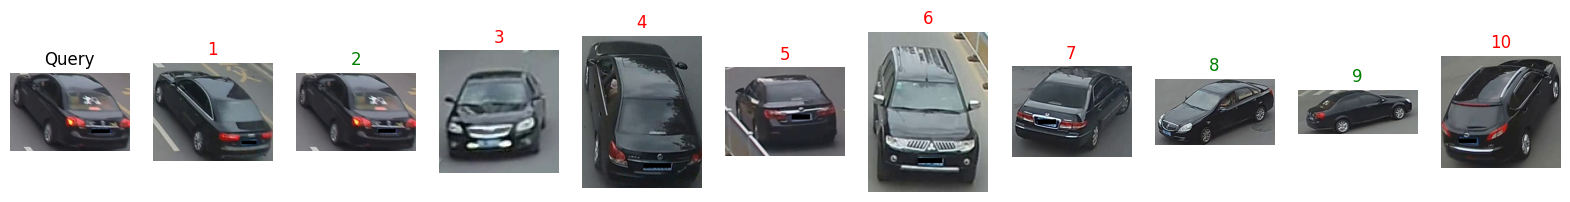

In [ ]:
visualize_top10(0)

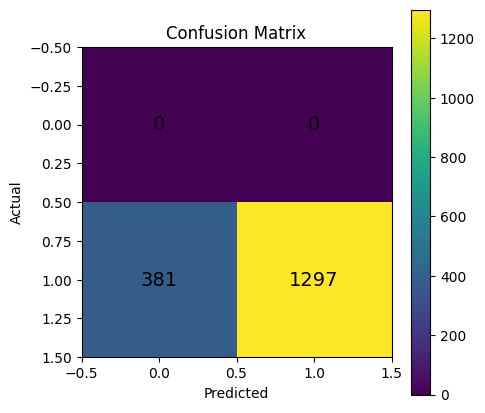

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', fontsize=14)

plt.show()

In [ ]:
def visualize_predictions(n=5):
    query_path = "/content/VeRi/image_query"
    gallery_path = "/content/VeRi/image_test"

    for i in range(n):
        qname = query_names[i]
        sims = similarity[i]
        idx = np.argsort(-sims)

        top1 = gallery_names[idx[0]]

        plt.figure(figsize=(6,3))

        # Query
        q_img = cv2.imread(os.path.join(query_path, qname))
        q_img = cv2.cvtColor(q_img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,2,1)
        plt.imshow(q_img)
        plt.title("Query")
        plt.axis('off')

        # Prediction
        g_img = cv2.imread(os.path.join(gallery_path, top1))
        g_img = cv2.cvtColor(g_img, cv2.COLOR_BGR2RGB)

        correct = get_id(qname) == get_id(top1)

        plt.subplot(1,2,2)
        plt.imshow(g_img)
        plt.title("Correct ✅" if correct else "Wrong ❌")
        plt.axis('off')

        plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


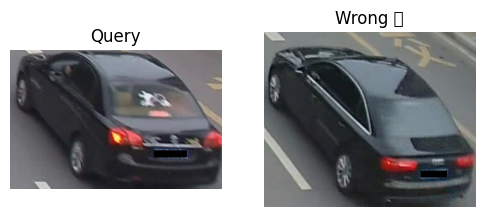

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


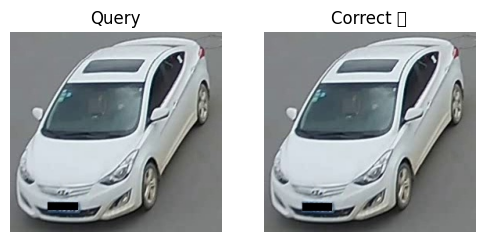

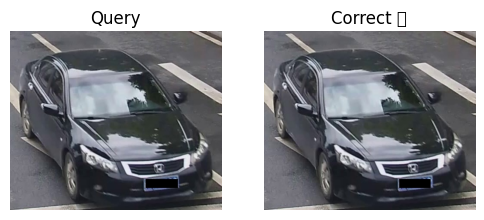

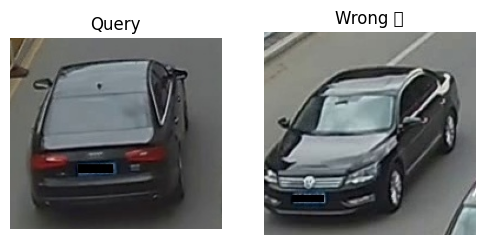

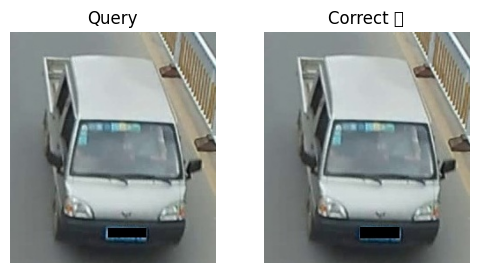

In [ ]:
visualize_predictions(5)

In [ ]:
def visualize_failures(max_fail=5):
    query_path = "/content/VeRi/image_query"
    gallery_path = "/content/VeRi/image_test"

    count = 0

    for i in range(len(query_names)):
        qname = query_names[i]
        sims = similarity[i]
        idx = np.argsort(-sims)

        top1 = gallery_names[idx[0]]

        if get_id(qname) != get_id(top1):

            plt.figure(figsize=(9,3))

            # Query
            q_img = cv2.imread(os.path.join(query_path, qname))
            q_img = cv2.cvtColor(q_img, cv2.COLOR_BGR2RGB)

            plt.subplot(1,3,1)
            plt.imshow(q_img)
            plt.title("Query")
            plt.axis('off')

            # Wrong
            wrong_img = cv2.imread(os.path.join(gallery_path, top1))
            wrong_img = cv2.cvtColor(wrong_img, cv2.COLOR_BGR2RGB)

            plt.subplot(1,3,2)
            plt.imshow(wrong_img)
            plt.title("Wrong ❌")
            plt.axis('off')

            # Correct (if exists)
            for j in idx:
                if get_id(gallery_names[j]) == get_id(qname):
                    correct_img = cv2.imread(os.path.join(gallery_path, gallery_names[j]))
                    correct_img = cv2.cvtColor(correct_img, cv2.COLOR_BGR2RGB)

                    plt.subplot(1,3,3)
                    plt.imshow(correct_img)
                    plt.title("Correct ✅")
                    plt.axis('off')
                    break

            plt.show()

            count += 1
            if count >= max_fail:
                break

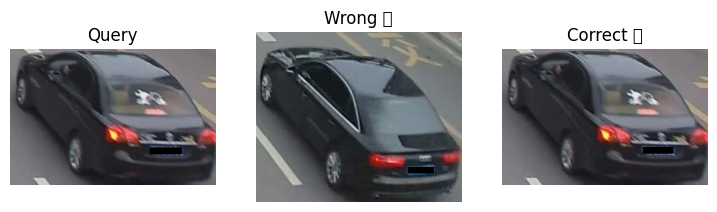

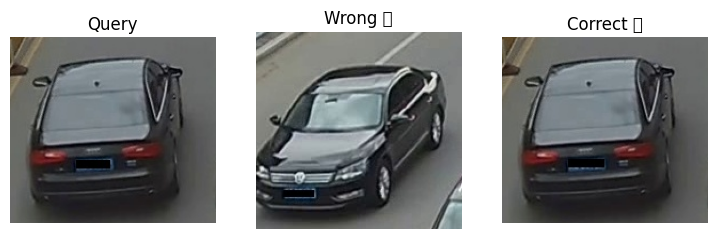

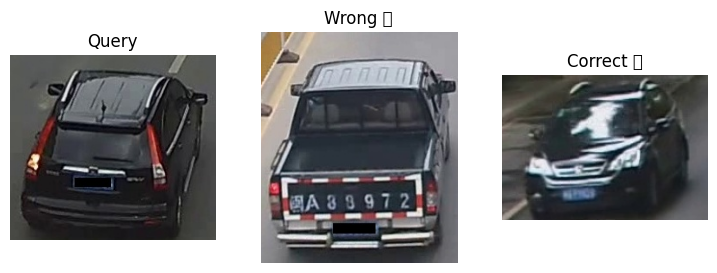

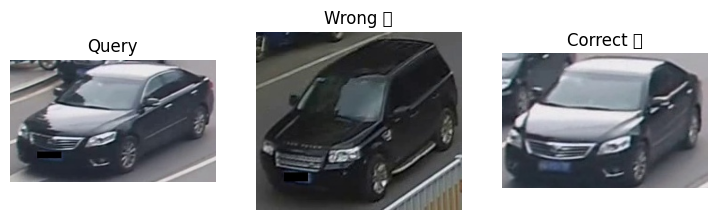

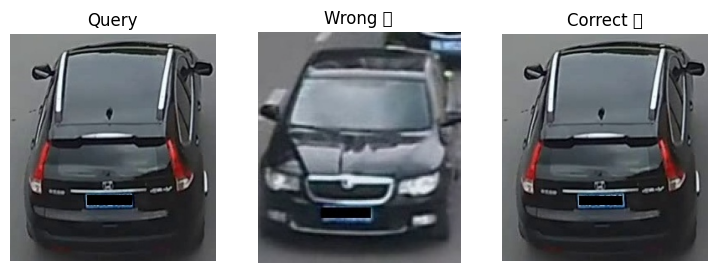

In [ ]:
visualize_failures(5)